**Cálculo Numérico y Programación**

**Aux. Daniel Roberto Garcia Miranda**

**Ecuaciones diferenciales**

**Sistemas de ecuaciones Diferenciales**

Un sistema de ecuaciones diferenciales se representa de forma general como:

$\frac{dy_1}{dx} = f_{1}(x,y_1,y_2, . . . , y_n)$

$\frac{dy_2}{dx} = f_{2}(x,y_1,y_2, . . . , y_n)$

. . .

$\frac{dy_n}{dx} = f_{n}(x,y_1,y_2, . . . , y_n)$

Para hallar la solución del sistema, se requieren n condiciones iniciales y aplicar a cada ecuación el método para resolver.


In [ ]:
##Ejemplo, sistema de ecuaciones diferenciales
#Primera ecuacion

def f1(y1,y2):
    return -0.5*y1
#Segunda ecuacion
def f2(y1,y2):
    return 4-0.3*y2-0.1*y1

#Parametros iniciales
y1_0 = 4
y2_0 = 6
xi = 0
xf = 2
h= 0.5

#Aplicamos el metodo de euler
y_eu_1 = y1_0
y_eu_2 = y2_0
while xi <= xf:
    print(xi, y_eu_1, y_eu_2)
    y_eu_1 = y1_0 + h*f1(y1_0,y2_0)
    y_eu_2 = y2_0 + h*f2(y1_0,y2_0)
    xi+=h
    y1_0 = y_eu_1
    y2_0 = y_eu_2
#Con el metodo de euler modificado (Heun)
y1_0 = 4
y2_0 = 6
xi = 0
xf = 2
h= 0.5
y_eum_1 = y1_0
y_eum_2 = y2_0
while xi <= xf:
    print(xi, y_eum_1, y_eum_2)
    #Calculamos los predictores
    y_p_1 = y1_0 + h*f1(y1_0,y2_0)
    y_p_2 = y2_0 + h*f2(y1_0,y2_0)
    #Calculamos la solucion
    y_eum_1 = y1_0 + 0.5*h*(f1(y1_0,y2_0)+f1(y_p_1,y_p_2))
    y_eum_2 = y2_0 + 0.5*h*(f2(y1_0,y2_0)+f2(y_p_1, y_p_2))
    xi+=h
    y1_0 = y_eum_1
    y2_0 = y_eum_2



**Ecuaciones diferenciales de 2do Orden**

Para resolver una ecuación diferencial de primer orden, con los métodos de Runge Kutta, teniamos las ecuaciones en la forma:

## $\frac{dy}{dx} = y' = f(x,y)$

Donde la solución está dada por:

## $y_{i+1} = y_i + \phi(x_i,y_i)h $

Ahora, una ecuación diferencial de segundo orden, tiene la forma general:

## $\frac{d^2y}{dx^2} = y'' = f(x,y,y')$

Para resolverla, vamos a transformar la ecuación, en un sistema de 2 ecuaciones diferenciales de primer orden:

# $\frac{dy}{dx} = y' = u$

# $\frac{du}{dx} = u' = f(x,y,y')$

In [ ]:
##Ejemplo de ecuaciones diferenciales de 2do Orden
#Solucion Practica 20 parte 2

import numpy as np

#El problema nos proporciona la solucion analitica
def freal(x):
    return (10/7)*np.exp(-5*x) + (18/7)*np.exp(2*x)
#La EDO es: y'' + 3y' -10y = 0, aca definimos las funciones u, y u'
#u1 = y, u2 = y'
def du1(u2):
    return u2

def du2(u1, u2):
    return 10*u1 - 3*u2


#Parametros iniciales
x0 = -0.2
u10 = 5.607
u20 = -15.9689
h = 0.1
#Resolvemos con el método de Euler modificado
while x0 <= 1.0:
    print(f"{x0:.4f}, {freal(x0):.4f}, {u10:.4f}, {u20:.4f}")
    #Calculamos los predictores
    u1_0 =u10 + h*du1(u20)
    u2_0 =u20 + h*du2(u10, u20)
    #Ahora los correctores
    k1_u1 = du1(u20)
    k2_u1 = du1(u2_0) #Aca u2_0 es la variable independiente de u1 (la x_{i+1}) como du1 solo depende de ésta, no utilizamos el predictor de u
    u1 = u10 + (h/2)*(k1_u1 + k2_u1)

    k1_u2 = du2(u10, u20)
    k2_u2 = du2(u1_0, u2_0) #En este caso du2 si depende de la variable dependiente (u2) asi que utilizamos su predictor
    u2 = u20 + (h/2)*(k1_u2 + k2_u2)
    
    u10, u20 = u1, u2
    x0+=h

Ejemplo, Práctica 22

![](Practica22.png)

<Axes: xlabel='t'>

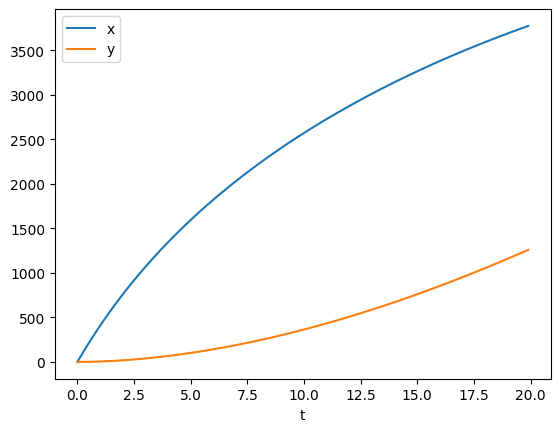

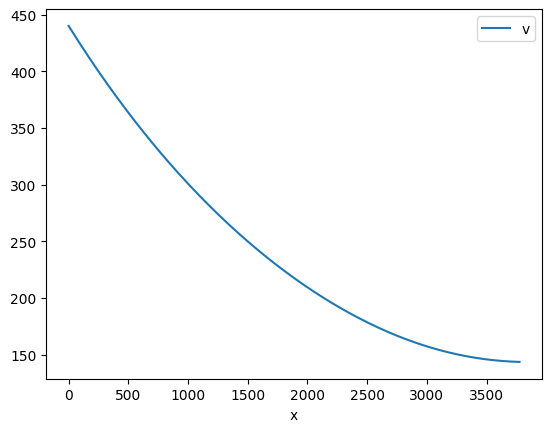

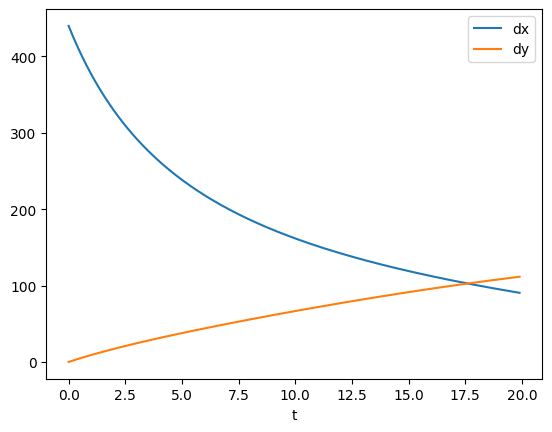

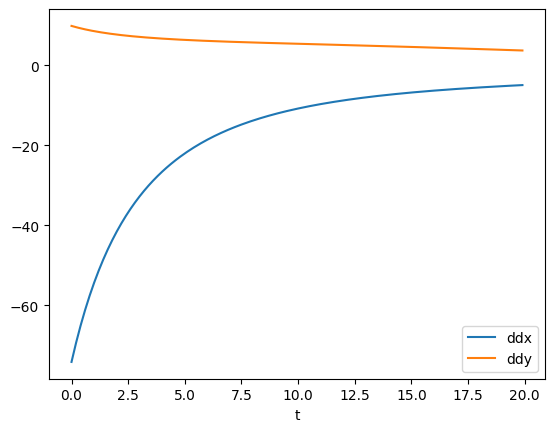

In [3]:
#Ejemplo de sistema de EDOs de segundo orden
#Solución práctica 22
import numpy as np
import pandas as pd
#Definimos
#u1 = x' = dx
#du1 = x'' = f1
#u2 = y' = dy
#du2 = y'' = f2
def f1(dx,dy):
    g = 9.8
    V = 160
    return -(g*dx*np.sqrt(dx**2+dy**2))/(V**2)
def f2(dx,dy):
    g = 9.8
    V = 160
    return g-(g*dy*np.sqrt(dx**2+dy**2))/(V**2)
def u1(dx):
    return dx
def u2(dy):
    return dy

#Valores iniciales
x0,y0,dx0, dy0 = 0, 0, 440,0
ddx = f1(dx0, dy0)
ddy = f2(dx0, dy0)
t = 0
h = 0.1

#Para crear el dataframe
resultados = []
while t <= 20:
    resultados.append([t, x0, y0, dx0, dy0, ddx, ddy])
    # print(f"{t:.4f} {x0:.4f} {y0:.4f} {dx0:.4f} {dy0:.4f} {ddx:.4f} {ddy:.4f}")
    #Calculamos los predictores
    x_p = x0 + h*u1(dx0)
    dx_p = dx0 + h*f1(dx0,dy0)
    y_p = y0 + h*u2(dy0)
    dy_p = dy0 + h*f2(dx0,dy0)
    #Calculamos las soluciones con el metodo de euler modificado (Heun)
    x_eu = x0 + 0.5*h*(u1(dx0)+u1(dx_p))
    dx_eu = dx0 + 0.5*h*(f1(dx0,dy0)+f1(dx_p,dy_p))
    y_eu = y0 + 0.5*h*(u2(dy0)+u2(dy_p))
    dy_eu = dy0 + 0.5*h*(f2(dx0,dy0)+f2(dx_p,dy_p))
    x0,y0,dx0,dy0 = x_eu, y_eu, dx_eu, dy_eu
    #Calculamos lo que nos pide, ddx, y ddy
    ddx = f1(dx0, dy0)
    ddy = f2(dx0, dy0)
    t+=h

df = pd.DataFrame(resultados, columns=["t", "x", "y", "dx", "dy", "ddx", "ddy"])
df['v'] = np.sqrt(df['dx']**2 + df['dy']**2)
# print(df)

df.plot(kind='line', x='t', y=['x', 'y'])
df.plot(kind='line', x='x', y=['v'])
df.plot(kind='line', x='t', y=['dx', 'dy'])
df.plot(kind='line', x='t', y=['ddx', 'ddy'])


<Axes: xlabel='t'>

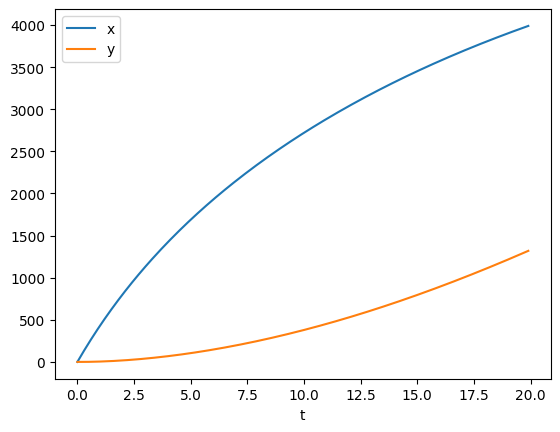

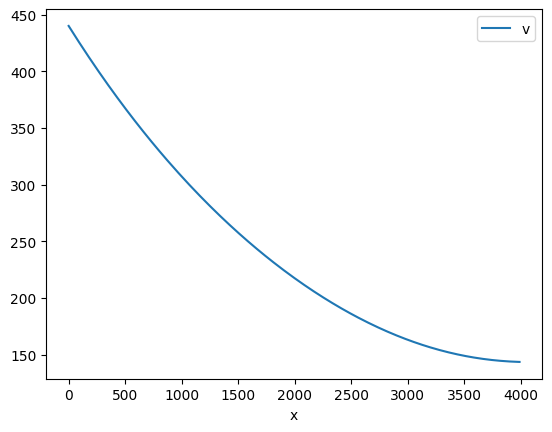

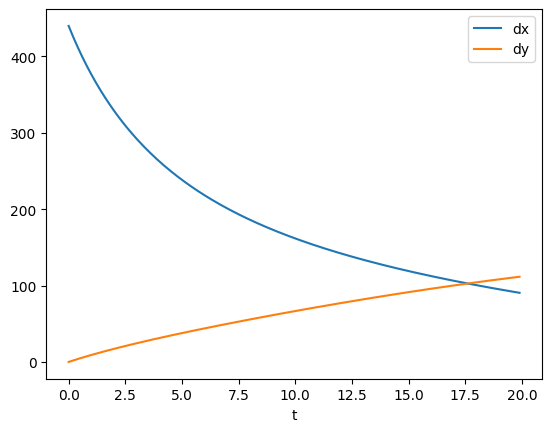

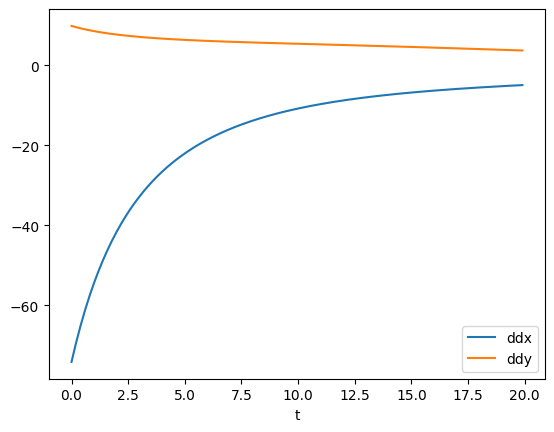

In [2]:
#Ejemplo de sistema de EDOs de segundo orden
#Solución práctica 22, parte dos, con runge kutta de 3er orden
import numpy as np
import pandas as pd
#Definimos
#u1 = x' = dx
#du1 = x'' = f1
#u2 = y' = dy
#du2 = y'' = f2
def f1(dx,dy):
    g = 9.8
    V = 160
    return -(g*dx*np.sqrt(dx**2+dy**2))/(V**2)
def f2(dx,dy):
    g = 9.8
    V = 160
    return g-(g*dy*np.sqrt(dx**2+dy**2))/(V**2)
def u1(dx):
    return dx
def u2(dy):
    return dy

#Valores iniciales
x0,y0,dx0, dy0 = 0, 0, 440,0
ddx = f1(dx0, dy0)
ddy = f2(dx0, dy0)
t = 0
h = 0.1

#Para crear el dataframe
resultados = []
while t <= 20:
    resultados.append([t, x0, y0, dx0, dy0, ddx, ddy])
    # print(f"{t:.4f} {x0:.4f} {y0:.4f} {dx0:.4f} {dy0:.4f} {ddx:.4f} {ddy:.4f}")
    #Calculamos los predictores
    k1_x = u1(dx0)
    k1_y = u2(dy0)
    k1_dx = f1(dx0, dy0)
    k1_dy = f2(dx0, dy0)

    k2_x = u1(dx0 + 0.5*k1_x*h)
    k2_y = u2(dy0 + 0.5*k1_y*h)
    k2_dx = f1(dx0 + 0.5*k1_dx*h, dy0 + 0.5*k1_dy*h)
    k2_dy = f2(dx0 + 0.5*k1_dx*h, dy0 + 0.5*k1_dy*h)

    k3_x = u1(dx0 - k1_x*h+2*k2_x*h)
    k3_y = u2(dy0 - k1_y*h+2*k2_y*h)
    k3_dx = f1(dx0 - k1_dx*h+2*k2_dx*h, dy0 - k1_dy*h + 2*k2_dy*h)
    k3_dy = f2(dx0 - k1_dx*h+2*k2_dx*h, dy0 - k1_dy*h + 2*k2_dy*h)

    #Calculamos las soluciones con Runge Kutta de 3er orden
    x_RK3 = x0 + (1/6)*(k1_x+4*k2_x + k3_x)*h
    dx_RK3 = dx0 + (1/6)*(k1_dx+4*k2_dx + k3_dx)*h
    y_RK3 = y0 + (1/6)*(k1_y+4*k2_y + k3_y)*h
    dy_RK3 = dy0 + (1/6)*(k1_dy+4*k2_dy + k3_dy)*h

    x0,y0,dx0,dy0 = x_RK3, y_RK3, dx_RK3, dy_RK3
    #Calculamos lo que nos pide, ddx, y ddy
    ddx = f1(dx0, dy0)
    ddy = f2(dx0, dy0)
    t+=h

df = pd.DataFrame(resultados, columns=["t", "x", "y", "dx", "dy", "ddx", "ddy"])
df['v'] = np.sqrt(df['dx']**2 + df['dy']**2)
# print(df)

df.plot(kind='line', x='t', y=['x', 'y'])
df.plot(kind='line', x='x', y=['v'])
df.plot(kind='line', x='t', y=['dx', 'dy'])
df.plot(kind='line', x='t', y=['ddx', 'ddy'])


## Ejercicio 25.24

**Ecuación diferencial:**

$$
\frac{d^2y}{dt^2} + 4y = 0
$$

**Condiciones iniciales:**  

$$
y(0) = 1, \quad y'(0) = 0
$$

**Intervalo:** $t = 0$ a $t = 4$

**Métodos numéricos:**  
a) Euler modificado
b) Runge-Kutta de 2do orden (RK2)

**Paso:** $h = 0.125$

**Requerimiento:** Graficar ambas soluciones numéricas junto con la solución exacta:

$$
y_{\text{exacta}}(t) = \cos(2t)
$$



## Ejercicio 25.25

**Sistema de EDOs de primer orden:**

$$
\frac{dy}{dt} = v
$$

$$
\frac{dv}{dt} = -g - \frac{c_d}{m} v |v|
$$

**Variables:**  
- $y$: altura (m)  
- $v$: velocidad vertical (m/s)  
- $t$: tiempo (s)

**Parámetros fijos:**  
$g = 9.81 \, \text{m/s}^2$, $m = 0.4 \, \text{kg}$, $\rho = 1.3 \, \text{kg/m}^3$, $C_d = 0.52$, $d = 22 \, \text{cm} = 0.22 \, \text{m}$

**Cálculo del coeficiente de arrastre $c_d$:**  

Área transversal:

$$
A = \pi \left( \frac{d}{2} \right)^2
$$

Coeficiente de arrastre:

$$
c_d = \frac{1}{2} \rho A C_d
$$

**Condiciones iniciales:**  

$$
y(0) = 0, \quad v(0) = 40 \, \text{m/s}
$$

**Requerimiento:** Calcular posición y velocidad del balón lanzado hacia arriba.

## Ejercicio 25.26

**Sistema de EDOs de segundo orden (tres jumpers en bungee):**

$$
m_1 \frac{d^2x_1}{dt^2} = m_1 g + k_1 (x_2 - x_1) - k_1 x_1
$$

$$
m_2 \frac{d^2x_2}{dt^2} = m_2 g + k_2 (x_3 - x_2) + k_2 (x_1 - x_2)
$$

$$
m_3 \frac{d^2x_3}{dt^2} = m_3 g + k_3 (x_2 - x_3)
$$

**Variables:**  
- $x_i$: desplazamiento del jumper $i$ hacia abajo desde su posición de equilibrio (m)  
- $m_i$: masa del jumper $i$ (kg)  
- $k_j$: constante del resorte del cordón $j$ (N/m)

**Parámetros:**  
$m_1 = 60 \, \text{kg}$, $m_2 = 70 \, \text{kg}$, $m_3 = 80 \, \text{kg}$  
$k_1 = 50 \, \text{N/m}$, $k_2 = 100 \, \text{N/m}$, $k_3 = 50 \, \text{N/m}$  
$g = 9.81 \, \text{m/s}^2$

**Condiciones iniciales:**  

$$
x_1(0) = 0,\; x_2(0) = 0,\; x_3(0) = 0
$$

$$
\dot{x}_1(0) = 0,\; \dot{x}_2(0) = 0,\; \dot{x}_3(0) = 0
$$

**Requerimiento:** Resolver para posiciones y velocidades de los tres jumpers.

![](Bungees.png)